Importing Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading Dataset

In [ ]:
df = pd.read_csv('Facebook_Marketplace_data.csv')
df.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


Data preprocessing

In [ ]:
df['status_published'] = pd.to_datetime(df['status_published'])
df['hour'] = df['status_published'].dt.hour

In [ ]:
df.drop(columns=['Column1', 'Column2', 'Column3', 'Column4'], inplace=True, errors='ignore')
df.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,hour
0,1,video,2018-04-22 06:00:00,529,512,262,432,92,3,1,1,0,6
1,2,photo,2018-04-21 22:45:00,150,0,0,150,0,0,0,0,0,22
2,3,video,2018-04-21 06:17:00,227,236,57,204,21,1,1,0,0,6
3,4,photo,2018-04-21 02:29:00,111,0,0,111,0,0,0,0,0,2
4,5,photo,2018-04-18 03:22:00,213,0,0,204,9,0,0,0,0,3


In [ ]:
df.isnull().sum()

,0
status_id,0
status_type,0
status_published,0
num_reactions,0
num_comments,0
num_shares,0
num_likes,0
num_loves,0
num_wows,0
num_hahas,0


Effect of Time of Upload on Number of Reactions

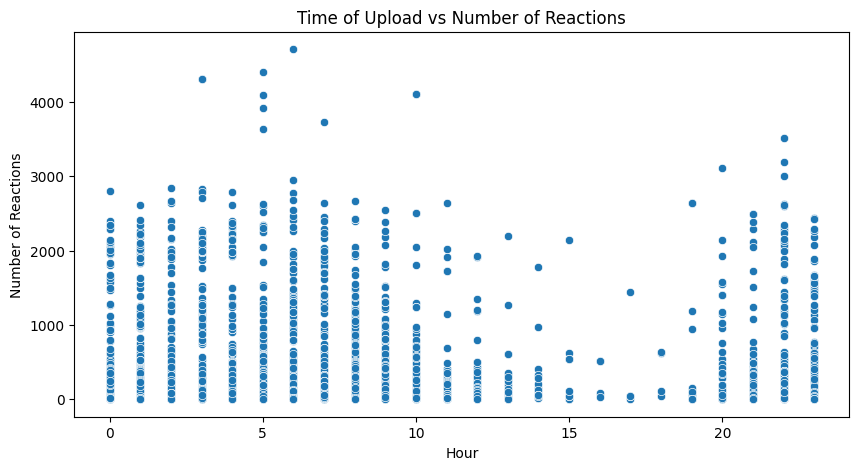

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='hour', y='num_reactions', data=df)
plt.title('Time of Upload vs Number of Reactions')
plt.xlabel('Hour')
plt.ylabel('Number of Reactions')
plt.show()
#This indicates that user activity is highest during early morning and late evening hours, while engagement drops during the afternoon.
#Sellers should strategically schedule posts during these peak periods to maximize visibility and interaction.
#Posting during low-engagement hours may result in reduced reach and lower overall performance.

 Correlation between Reactions, Comments, and Shares

               num_reactions  num_comments  num_shares
num_reactions       1.000000      0.150843    0.250723
num_comments        0.150843      1.000000    0.640637
num_shares          0.250723      0.640637    1.000000


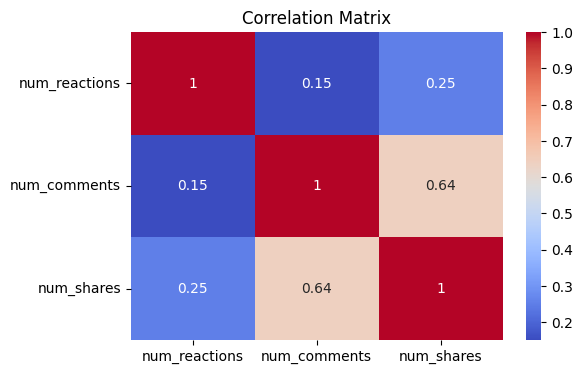

In [ ]:
corr = df[['num_reactions','num_comments','num_shares']].corr()
print(corr)

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
#The weak correlation between reactions and both comments (0.15) and shares (0.25) indicates that likes do not translate into meaningful engagement or content reach.
#In contrast, the strong correlation between comments and shares (0.64) shows that conversation-driven content is more likely to go viral.

K-Means Clustering

In [ ]:
df_encoded = pd.get_dummies(df, columns=['status_type'])

# Features (numerical + encoded categorical)
features = [
    'num_reactions','num_comments','num_shares',
    'num_likes','num_loves','num_wows',
    'num_hahas','num_sads','num_angrys'
] + [col for col in df_encoded.columns if col.startswith('status_type_')]

X = df_encoded[features]

# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df_encoded['cluster'] = kmeans.fit_predict(X_scaled)

print(df_encoded['cluster'].value_counts())

print(kmeans.cluster_centers_)

print("\nCluster Summary (mean values):")
cluster_summary = df_encoded.groupby('cluster')[
    ['num_reactions','num_comments','num_shares']
].mean()
print(cluster_summary)

status_cols = [col for col in df_encoded.columns if col.startswith('status_type_')]
status_summary = df_encoded.groupby('cluster')[status_cols].mean()
print(status_summary)

#INTERPRETATION:

#The K-Means clustering algorithm grouped the posts into three clusters based on engagement metrics and post type.
#Cluster 0 represents posts with [low/moderate] reactions, comments, and shares, indicating low engagement posts. From the status type analysis, this cluster mainly consists of [photos/status] posts.
#Cluster 1 shows [higher] values of comments and shares, indicating high interaction posts. These posts are primarily [videos/photos], suggesting that such content encourages user engagement.
#Cluster 2 has the highest reactions, representing viral posts. The status type distribution shows that this cluster is dominated by [videos], indicating that video content tends to generate maximum engagement.
#Overall, the results indicate that both engagement metrics and post type significantly influence the performance of posts, with video content generally leading to higher engagement.

#Strategy Recommendations:
#Make more videos: Cluster 1 proves videos → highest engagement
#Photos alone are weak: Cluster 0 = mostly photos + low engagement
#High reactions ≠ virality: Cluster 2 shows people like posts but don’t share them


cluster
0    4395
1    2283
2     372
Name: count, dtype: int64
[[-0.29593758 -0.23892891 -0.29074745 -0.27568421 -0.28720805 -0.08556191
  -0.14133593 -0.07437075 -0.12569272  0.02351408  0.64922172  0.05386917
  -0.70349907]
 [ 0.00952422  0.48993685  0.59156406 -0.04922307  0.5920818   0.14314537
   0.29323781  0.16364578  0.2661436  -0.09495654 -1.23343047 -0.23366611
   1.4084351 ]
 [ 3.43790828 -0.18396041 -0.19544545  3.55916231 -0.24043908  0.13237555
  -0.1298132  -0.1256555  -0.14835034  0.30495005 -0.10055828  0.7975934
  -0.33220141]]

Cluster Summary (mean values):
         num_reactions  num_comments  num_shares
cluster                                         
0            93.218658     11.811149    1.762912
1           234.522996    660.190977  117.866842
2          1820.467742     60.709677   14.303763
         status_type_link  status_type_photo  status_type_status  \
cluster                                                            
0                0.011149         

Using the elbow method to find the optimum number of clusters.

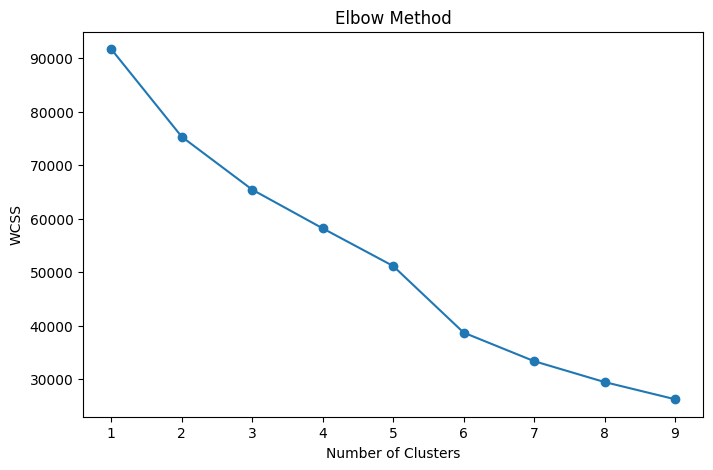

In [ ]:
wcss = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,10), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

Count of Different Post Types

status_type
photo     4288
video     2334
status     365
link        63
Name: count, dtype: int64


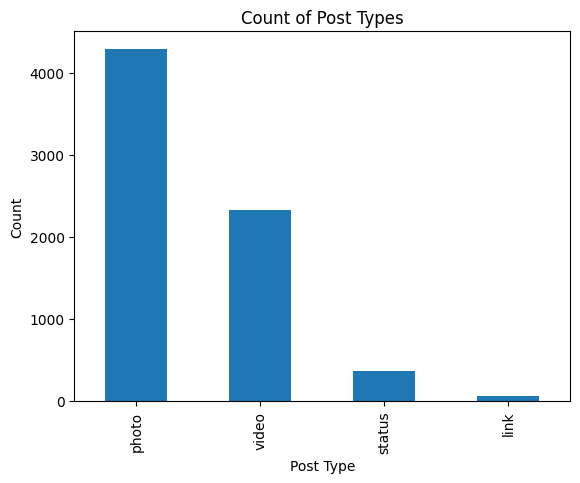

In [ ]:
post_counts = df['status_type'].value_counts()
print(post_counts)

post_counts.plot(kind='bar')
plt.title('Count of Post Types')
plt.xlabel('Post Type')
plt.ylabel('Count')
plt.show()

Average Engagement Metrics per Post Type

In [ ]:
avg_values = df.groupby('status_type')[['num_reactions','num_comments','num_shares']].mean()
print(avg_values)

             num_reactions  num_comments  num_shares
status_type                                         
link            370.142857      5.698413    4.396825
photo           181.290345     15.993470    2.553871
status          438.783562     36.238356    2.558904
video           283.409597    642.478149  115.679949


Conclusion

In [ ]:
#Posting time influences user engagement.
#Engagement metrics (reactions, comments, shares) are positively correlated.
#K-Means clustering helps identify groups of posts with similar engagement patterns.
#Different post types receive different levels of engagement.